# Covid19 Data Analysis Notebook
------------------------------------------

### Let's Import the modules 

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
print('Modules are imported.')

Modules are imported.


### Importing covid19 dataset

In [2]:
corona_dataset_csv = pd.read_csv("Datasets/covid19_Confirmed_dataset.csv")
corona_dataset_csv.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20
0,NaN,Afghanistan,33.0000,65.0000,0,0,0,0,0,0,...,1092,1176,1279,1351,1463,1531,1703,1828,1939,2171
1,NaN,Albania,41.1533,20.1683,0,0,0,0,0,0,...,609,634,663,678,712,726,736,750,766,773
2,NaN,Algeria,28.0339,1.6596,0,0,0,0,0,0,...,2811,2910,3007,3127,3256,3382,3517,3649,3848,4006
3,NaN,Andorra,42.5063,1.5218,0,0,0,0,0,0,...,717,723,723,731,738,738,743,743,743,745
4,NaN,Angola,-11.2027,17.8739,0,0,0,0,0,0,...,24,25,25,25,25,26,27,27,27,27


#### Let's check the shape of the dataframe

In [3]:
corona_dataset_csv.shape

(266, 104)

### Delete the useless columns

In [4]:
corona_dataset_csv.drop(['Lat','Long'],axis=1,inplace = True)

In [5]:
corona_dataset_csv.head()

,Province/State,Country/Region,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,...,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20
0,NaN,Afghanistan,0,0,0,0,0,0,0,0,...,1092,1176,1279,1351,1463,1531,1703,1828,1939,2171
1,NaN,Albania,0,0,0,0,0,0,0,0,...,609,634,663,678,712,726,736,750,766,773
2,NaN,Algeria,0,0,0,0,0,0,0,0,...,2811,2910,3007,3127,3256,3382,3517,3649,3848,4006
3,NaN,Andorra,0,0,0,0,0,0,0,0,...,717,723,723,731,738,738,743,743,743,745
4,NaN,Angola,0,0,0,0,0,0,0,0,...,24,25,25,25,25,26,27,27,27,27


### Aggregating the rows by the country

In [6]:
corona_dataset_aggregated = corona_dataset_csv.groupby('Country/Region').sum()

In [7]:
corona_dataset_aggregated.head()

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0,0,0,0,0,0,0,0,0,0,...,1092,1176,1279,1351,1463,1531,1703,1828,1939,2171
Albania,0,0,0,0,0,0,0,0,0,0,...,609,634,663,678,712,726,736,750,766,773
Algeria,0,0,0,0,0,0,0,0,0,0,...,2811,2910,3007,3127,3256,3382,3517,3649,3848,4006
Andorra,0,0,0,0,0,0,0,0,0,0,...,717,723,723,731,738,738,743,743,743,745
Angola,0,0,0,0,0,0,0,0,0,0,...,24,25,25,25,25,26,27,27,27,27


In [8]:
corona_dataset_aggregated.shape

(187, 100)

### Visualizing data related to a country for example China

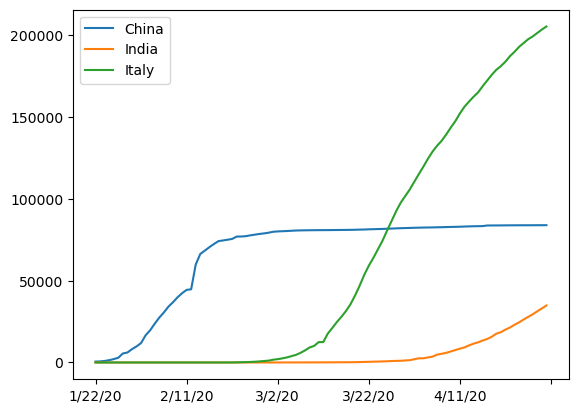

In [9]:
corona_dataset_aggregated.loc['China'].plot()
corona_dataset_aggregated.loc['India'].plot()
corona_dataset_aggregated.loc['Italy'].plot()
plt.legend()

###  Calculating a good measure 

<AxesSubplot: >

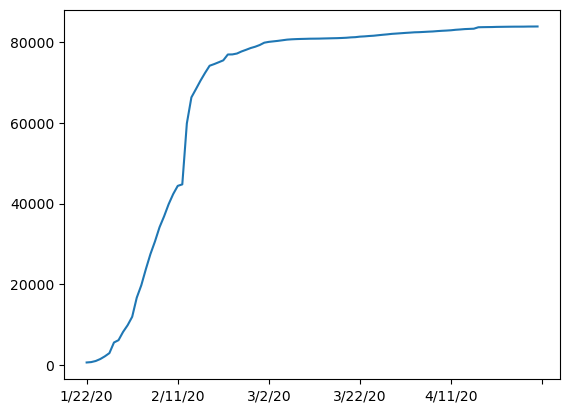

In [10]:
corona_dataset_aggregated.loc['China'].plot()

<AxesSubplot: >

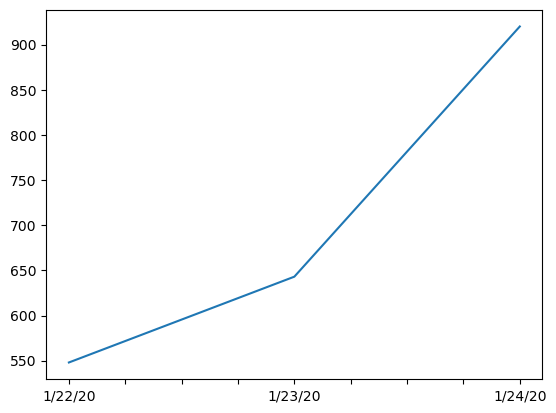

In [11]:
corona_dataset_aggregated.loc['China'][:3].plot()

###  caculating the first derivative of the curve

<AxesSubplot: >

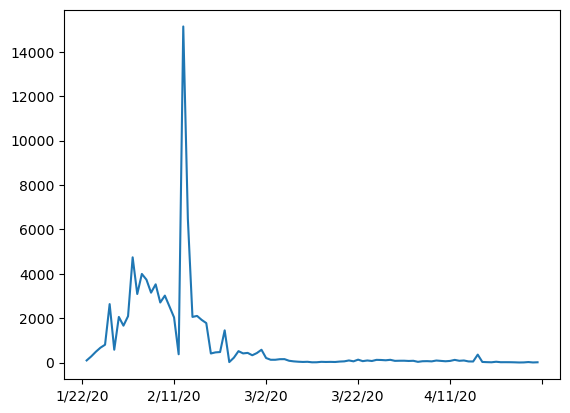

In [12]:
corona_dataset_aggregated.loc['China'].diff().plot()

###  find maxmimum infection rate for China

In [13]:
corona_dataset_aggregated.loc['China'].diff().max()

15136.0

In [14]:
corona_dataset_aggregated.loc['India'].diff().max()

1893.0

In [15]:
corona_dataset_aggregated.loc['Italy'].diff().max()

6557.0

### find maximum infection rate for all of the countries. 

In [16]:
countries = list(corona_dataset_aggregated.index)
max_infection_rate= []
for c in countries:
    max_infection_rate.append(corona_dataset_aggregated.loc[c].diff().max())
corona_dataset_aggregated['max_infection_rate'] = max_infection_rate

In [17]:
corona_dataset_aggregated.head()

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20,max_infection_rate
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0,0,0,0,0,0,0,0,0,0,...,1176,1279,1351,1463,1531,1703,1828,1939,2171,232.0
Albania,0,0,0,0,0,0,0,0,0,0,...,634,663,678,712,726,736,750,766,773,34.0
Algeria,0,0,0,0,0,0,0,0,0,0,...,2910,3007,3127,3256,3382,3517,3649,3848,4006,199.0
Andorra,0,0,0,0,0,0,0,0,0,0,...,723,723,731,738,738,743,743,743,745,43.0
Angola,0,0,0,0,0,0,0,0,0,0,...,25,25,25,25,26,27,27,27,27,5.0


###  create a new dataframe with only needed column 

In [18]:
corona_dataset = pd.DataFrame(corona_dataset_aggregated['max_infection_rate'])

In [19]:
corona_dataset.head()

,max_infection_rate
Country/Region,
Afghanistan,232.0
Albania,34.0
Algeria,199.0
Andorra,43.0
Angola,5.0


###  Importing the dataset

In [20]:
happiness_report_csv= pd.read_csv('Datasets/worldwide_happiness_report.csv')

In [21]:
happiness_report_csv.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


### let's drop the useless columns 

In [22]:
useless_cols = ['Overall rank','Score','Generosity','Perceptions of corruption']

In [23]:
happiness_report_csv.drop(useless_cols,inplace=True,axis=1)

In [24]:
happiness_report_csv.head()

,Country or region,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices
0,Finland,1.340,1.587,0.986,0.596
1,Denmark,1.383,1.573,0.996,0.592
2,Norway,1.488,1.582,1.028,0.603
3,Iceland,1.380,1.624,1.026,0.591
4,Netherlands,1.396,1.522,0.999,0.557


### Changing the indices of the dataframe

In [25]:
happiness_report_csv.set_index('Country or region',inplace = True)

###  now let's join two dataset we have prepared  

#### Corona Dataset :

In [26]:
corona_dataset.head()

,max_infection_rate
Country/Region,
Afghanistan,232.0
Albania,34.0
Algeria,199.0
Andorra,43.0
Angola,5.0


In [27]:
corona_dataset.shape

(187, 1)

#### wolrd happiness report Dataset :

In [28]:
happiness_report_csv.head()

,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices
Country or region,,,,
Finland,1.340,1.587,0.986,0.596
Denmark,1.383,1.573,0.996,0.592
Norway,1.488,1.582,1.028,0.603
Iceland,1.380,1.624,1.026,0.591
Netherlands,1.396,1.522,0.999,0.557


In [29]:
happiness_report_csv.shape

(156, 4)

In [30]:
data = corona_dataset.join(happiness_report_csv,how='inner')

In [31]:
data.head()

,max_infection_rate,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices
Afghanistan,232.0,0.350,0.517,0.361,0.000
Albania,34.0,0.947,0.848,0.874,0.383
Algeria,199.0,1.002,1.160,0.785,0.086
Argentina,291.0,1.092,1.432,0.881,0.471
Armenia,134.0,0.850,1.055,0.815,0.283


###  correlation matrix 

In [32]:
data.corr()

,max_infection_rate,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices
max_infection_rate,1.000000,0.250118,0.191958,0.289263,0.078196
GDP per capita,0.250118,1.000000,0.759468,0.863062,0.394603
Social support,0.191958,0.759468,1.000000,0.765286,0.456246
Healthy life expectancy,0.289263,0.863062,0.765286,1.000000,0.427892
Freedom to make life choices,0.078196,0.394603,0.456246,0.427892,1.000000


###  Visualization of the results

In [33]:
data.head()

,max_infection_rate,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices
Afghanistan,232.0,0.350,0.517,0.361,0.000
Albania,34.0,0.947,0.848,0.874,0.383
Algeria,199.0,1.002,1.160,0.785,0.086
Argentina,291.0,1.092,1.432,0.881,0.471
Armenia,134.0,0.850,1.055,0.815,0.283


###  Plotting GDP vs maximum Infection rate

<AxesSubplot: xlabel='GDP per capita', ylabel='max_infection_rate'>

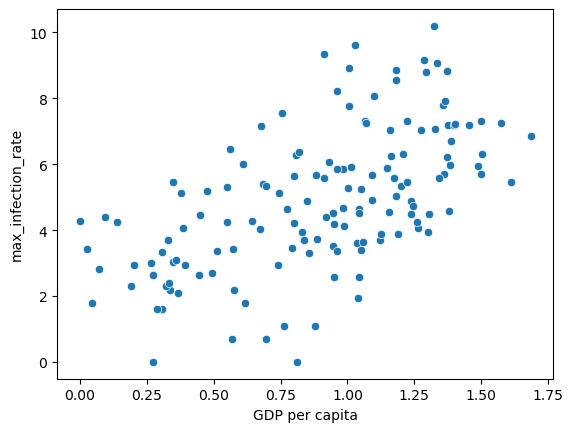

In [38]:
x = data['GDP per capita']
y = data['max_infection_rate']
sns.scatterplot(x=x,y=np.log(y))

<AxesSubplot: xlabel='GDP per capita', ylabel='max_infection_rate'>

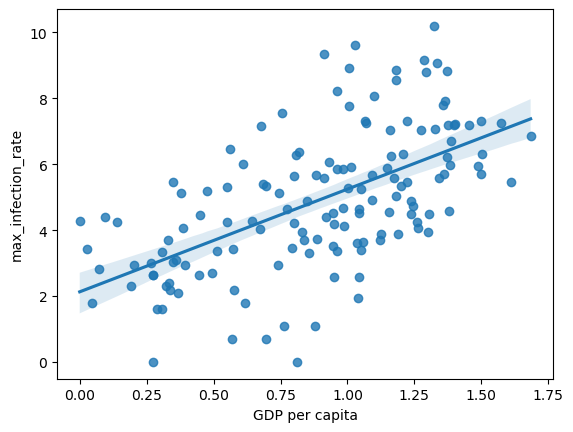

In [39]:
sns.regplot(x=x,y=np.log(y))

###  Plotting Social support vs maximum Infection rate

<AxesSubplot: xlabel='Social support', ylabel='max_infection_rate'>

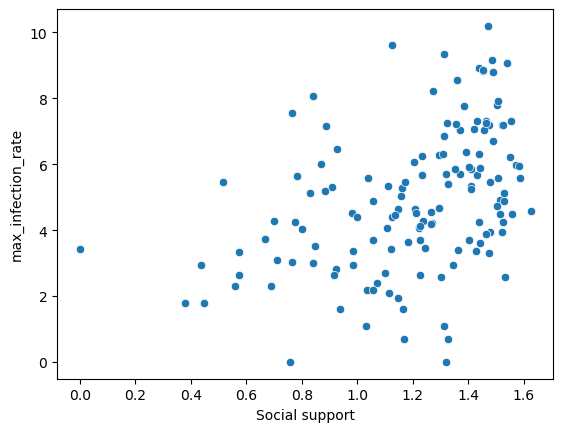

In [45]:
y = data['max_infection_rate']
sns.scatterplot(x='Social support',y=np.log(y),data=data)

<AxesSubplot: xlabel='Social support', ylabel='max_infection_rate'>

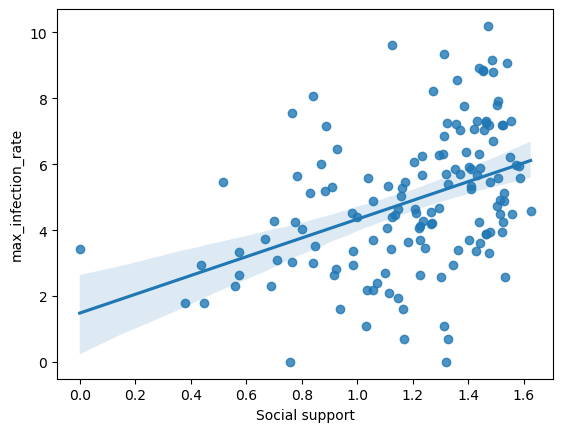

In [46]:
sns.regplot(x='Social support',y=np.log(y),data=data)

###  Plotting Healthy life expectancy vs maximum Infection rate

<AxesSubplot: xlabel='Healthy life expectancy', ylabel='max_infection_rate'>

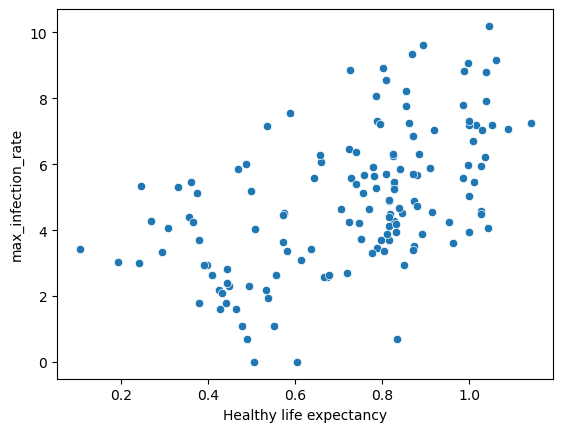

In [47]:
y = data['max_infection_rate']
sns.scatterplot(x='Healthy life expectancy',y=np.log(y),data=data)

<AxesSubplot: xlabel='Healthy life expectancy', ylabel='max_infection_rate'>

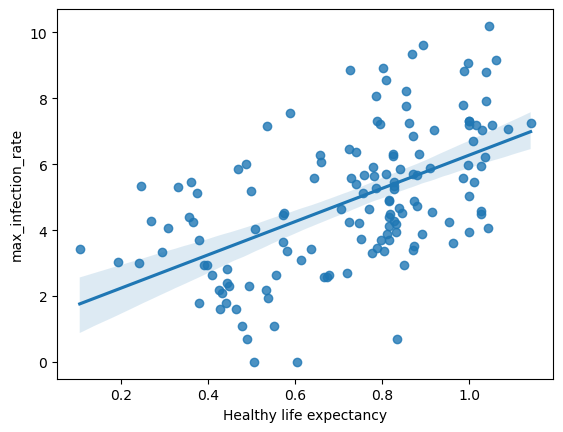

In [48]:
sns.regplot(x='Healthy life expectancy',y=np.log(y),data=data)

###  Plotting Freedom to make life choices vs maximum Infection rate

<AxesSubplot: xlabel='Freedom to make life choices', ylabel='max_infection_rate'>

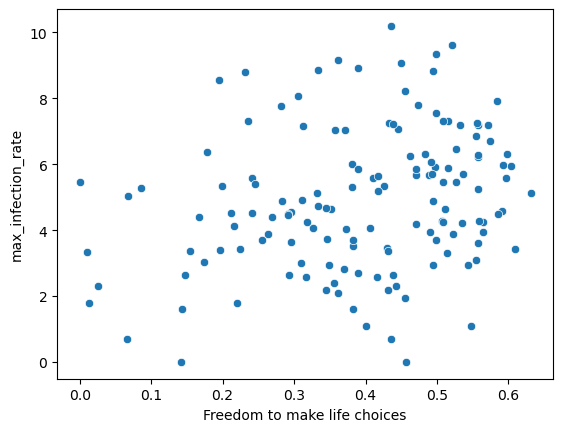

In [49]:
y = data['max_infection_rate']
sns.scatterplot(x='Freedom to make life choices',y=np.log(y),data=data)

<AxesSubplot: xlabel='Freedom to make life choices', ylabel='max_infection_rate'>

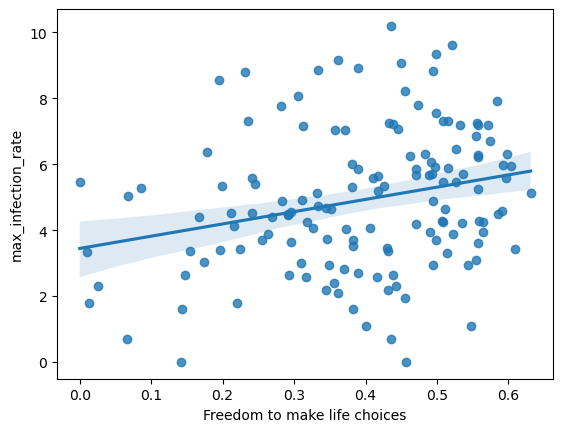

In [50]:
sns.regplot(x='Freedom to make life choices',y=np.log(y),data=data)